# 03_instrument_diagnostics_and_macro_merge.ipynb
## Does Δ²CGI work as an instrument? Full validation.

This notebook answers the one question that determines whether the index you built is useful:
**does Δ²CGI have enough first-stage power to instrument lpri?**

It also merges the composite GPR panel with the Saadaoui estimation dataset (df_extended.csv),
producing the master panel ready for DML and LP-IV in the next notebook.

**Run every cell in order. The output of Cell 6 (first-stage F) is the key diagnostic.**


## Cell 1 — Imports & Paths


In [1]:
from pathlib import Path
import warnings, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats
import statsmodels.api as sm
from statsmodels.tools.tools import add_constant
from statsmodels.tsa.stattools import grangercausalitytests
from linearmodels.iv import IV2SLS

warnings.filterwarnings('ignore')
np.random.seed(42)
plt.rcParams.update({'figure.dpi':120,'figure.facecolor':'white',
                     'axes.spines.top':False,'axes.spines.right':False})

ROOT     = Path(r'C:\Users\HP\Desktop\replication+contribution')
FINAL    = ROOT / 'data' / 'final'
OUT_03C  = ROOT / 'outputs' / '03c'
OUT_DIAG = ROOT / 'outputs' / '04_diagnostics'
OUT_DIAG.mkdir(parents=True, exist_ok=True)

print('Paths set.')
print(f'Composite panel exists: {(OUT_03C / "composite_gpr_panel.parquet").exists()}')
print(f'df_extended exists:     {(FINAL / "df_extended.csv").exists()}')


Paths set.
Composite panel exists: True
df_extended exists:     True


## Cell 2 — Load the composite GPR panel

Load the parquet output from 03_again.ipynb. We only need CHN-USA for the main instrument
diagnostics (since df_extended.csv is the CHN-USA estimation dataset from Saadaoui).


In [2]:
composite = pd.read_parquet(OUT_03C / 'composite_gpr_panel.parquet')
composite['date'] = pd.to_datetime(composite['date'])
composite = composite.sort_values(['dyad','date']).reset_index(drop=True)

print(f'Composite panel: {composite.shape}')
print(f'Dyads: {sorted(composite["dyad"].unique())}')
print(f'Date range: {composite["date"].min().date()} to {composite["date"].max().date()}')
print()

# CHN-USA slice
usa = composite[composite['dyad']=='CHN-USA'].copy()
usa['month'] = usa['date'].dt.to_period('M').dt.to_timestamp()
usa = usa.set_index('month').sort_index()

print('CHN-USA composite GPR summary:')
key_cols = [c for c in ['composite_gpr','delta2_cgi','delta1_cgi',
                         'gdelt_score_z','icews_score_z','sentiment_score_z']
            if c in usa.columns]
print(usa[key_cols].describe().round(4))


Composite panel: (4179, 21)
Dyads: ['CHN-AUS', 'CHN-DEU', 'CHN-FRA', 'CHN-GBR', 'CHN-IDN', 'CHN-IND', 'CHN-JPN', 'CHN-PAK', 'CHN-RUS', 'CHN-USA', 'CHN-VNM']
Date range: 1990-01-01 to 2022-02-01

CHN-USA composite GPR summary:
       composite_gpr  delta2_cgi  delta1_cgi  gdelt_score_z  icews_score_z  \
count       386.0000    384.0000    385.0000       380.0000       314.0000   
mean         -0.0171     -0.0005      0.0024        -0.0109        -0.0083   
std           0.7178      1.4968      0.8702         0.9574         0.9525   
min          -2.5894     -9.1213     -5.2586        -2.5894        -3.0000   
25%          -0.4330     -0.7869     -0.4485        -0.5422        -0.6325   
50%          -0.0207     -0.0071      0.0269         0.0848        -0.1761   
75%           0.3308      0.7594      0.4049         0.5506         0.4599   
max           3.0000      8.0277      4.7935         3.0000         3.0000   

       sentiment_score_z  
count           107.0000  
mean             

## Cell 3 — Load df_extended.csv (Saadaoui estimation dataset)

This is the dataset from notebooks 01-05: 385 observations, CHN-USA, 1990-2022.
We merge the composite GPR features onto it by date.


In [3]:
df_ext = pd.read_csv(FINAL / 'df_extended.csv', index_col=0, parse_dates=True)
df_ext.index = pd.to_datetime(df_ext.index).to_period('M').to_timestamp()
df_ext = df_ext.sort_index()

with open(FINAL / 'variable_roles.json') as f:
    roles = json.load(f)
_DROP = {'baa10y','tb3ms','l2lwip'}
CONTROLS = [c for c in roles['controls_core']+roles['controls_macro']+roles['controls_geopol']
            if c not in _DROP and c in df_ext.columns]

print(f'df_extended: {df_ext.shape}')
print(f'Date: {df_ext.index.min().date()} to {df_ext.index.max().date()}')
print(f'Controls ({len(CONTROLS)}): {CONTROLS}')
print()

# Merge composite GPR onto df_extended
gpr_cols = [c for c in ['composite_gpr','delta2_cgi','delta1_cgi',
                          'gdelt_score_z','icews_score_z','swb_score_z',
                          'nyt_score_z','sentiment_score_z']
            if c in usa.columns]
m = df_ext.join(usa[gpr_cols], how='left')

print(f'Merged dataset: {m.shape}')
print()
print('GPR feature coverage in estimation sample:')
for col in gpr_cols:
    n_nonull = m[col].notna().sum()
    pct = n_nonull / len(m) * 100
    print(f'  {col:25s}: {n_nonull}/{len(m)} ({pct:.1f}%)')


df_extended: (385, 20)
Date: 1990-02-01 to 2022-02-01
Controls (12): ['llwip', 'dllgop', 'dl2lgop', 'vix', 'gs10', 'brent', 'gold', 'bdi', 'cny_usd', 'indpro', 'gpr_chn_l1', 'gpr_usa_l1']

Merged dataset: (385, 28)

GPR feature coverage in estimation sample:
  composite_gpr            : 385/385 (100.0%)
  delta2_cgi               : 384/385 (99.7%)
  delta1_cgi               : 385/385 (100.0%)
  gdelt_score_z            : 379/385 (98.4%)
  icews_score_z            : 314/385 (81.6%)
  swb_score_z              : 192/385 (49.9%)
  nyt_score_z              : 329/385 (85.5%)
  sentiment_score_z        : 107/385 (27.8%)


## Cell 4 — Visual Validation: Does the index spike at known events?

Before any regression, check qualitatively: does Δ²CGI show large values at
months when US-China relations sharply changed? If the index is working, you
should see notable spikes at: 1996-03 (Taiwan Strait), 1999-05 (Belgrade bombing),
2001-04 (EP-3), 2018-03 (trade war), 2020-01 (COVID).

This is the same validation Bondarenko et al. (2026) do for their euro area index.


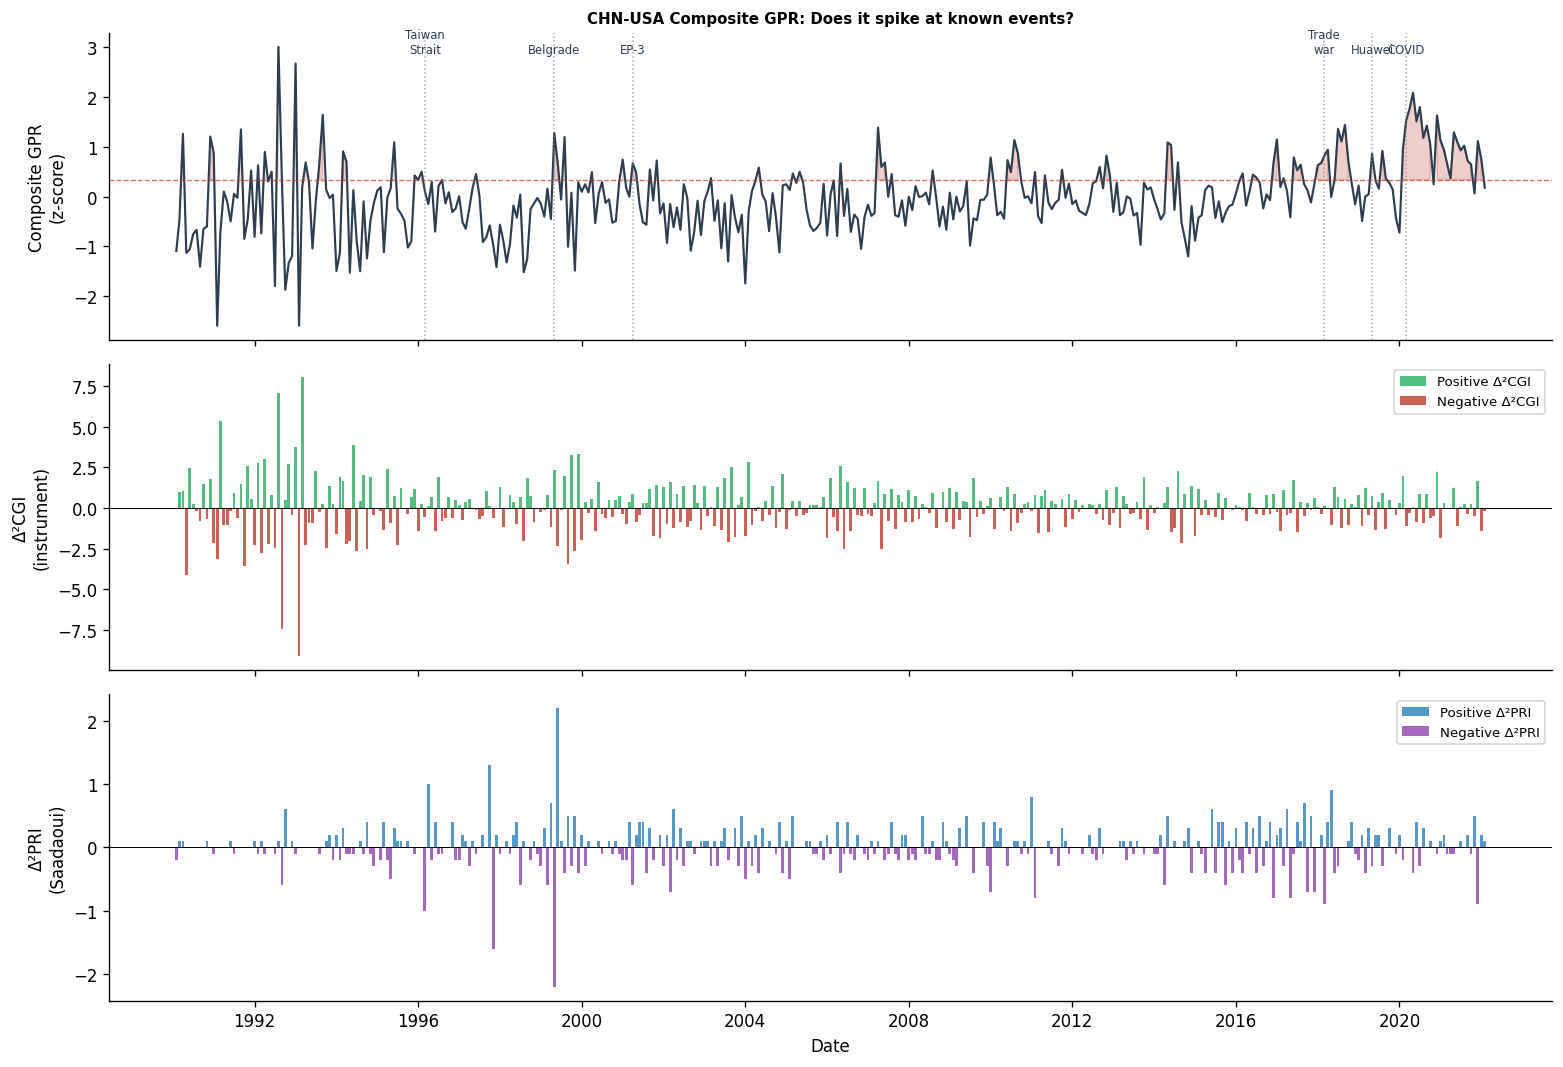

Saved: instrument_comparison_timeseries.png
Correlation Δ²PRI vs Δ²CGI: r=-0.1792, p=0.0004
Expected: LOW (|r| < 0.3) — they capture complementary dimensions
CONFIRMED: The two instruments are complementary, not redundant.


In [4]:
fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True)

EVENTS = {
    '1996-03': 'Taiwan\nStrait', '1999-05': 'Belgrade',
    '2001-04': 'EP-3', '2018-03': 'Trade\nwar',
    '2019-05': 'Huawei', '2020-03': 'COVID',
}

# Panel 1: Composite GPR level
ax = axes[0]
s = m['composite_gpr'].dropna()
ax.plot(s.index, s, color='#2C3E50', lw=1.3)
q75 = s.quantile(0.75)
ax.fill_between(s.index, s, q75, where=s > q75, alpha=0.25, color='#C0392B')
ax.axhline(q75, color='#C0392B', ls='--', lw=0.8, alpha=0.7)
ax.set_ylabel('Composite GPR\n(z-score)')
ax.set_title('CHN-USA Composite GPR: Does it spike at known events?', fontweight='bold', fontsize=9)
for d, label in EVENTS.items():
    try:
        ax.axvline(pd.Timestamp(d), color='grey', ls=':', lw=0.9, alpha=0.7)
        ax.text(pd.Timestamp(d), ax.get_ylim()[1] * 0.88, label,
                fontsize=7, ha='center', color='#2C3E50')
    except: pass

# Panel 2: Δ²CGI (the instrument)
ax = axes[1]
if 'delta2_cgi' in m.columns:
    d2 = m['delta2_cgi'].dropna()
    pos = d2.clip(lower=0); neg = d2.clip(upper=0)
    ax.bar(d2.index, pos, color='#27AE60', width=25, alpha=0.8, label='Positive Δ²CGI')
    ax.bar(d2.index, neg, color='#C0392B', width=25, alpha=0.8, label='Negative Δ²CGI')
    ax.axhline(0, color='black', lw=0.6)
    ax.set_ylabel('Δ²CGI\n(instrument)')
    ax.legend(fontsize=8)

# Panel 3: Δ²PRI (Saadaoui's instrument — for comparison)
ax = axes[2]
if 'd2pri' in m.columns:
    d2p = m['d2pri'].dropna()
    pos = d2p.clip(lower=0); neg = d2p.clip(upper=0)
    ax.bar(d2p.index, pos, color='#2980B9', width=25, alpha=0.8, label='Positive Δ²PRI')
    ax.bar(d2p.index, neg, color='#8E44AD', width=25, alpha=0.8, label='Negative Δ²PRI')
    ax.axhline(0, color='black', lw=0.6)
    ax.set_ylabel('Δ²PRI\n(Saadaoui)')
    ax.legend(fontsize=8)
ax.set_xlabel('Date')

plt.tight_layout()
plt.savefig(OUT_DIAG / 'instrument_comparison_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: instrument_comparison_timeseries.png')

# Correlation between Δ²CGI and Δ²PRI
if 'd2pri' in m.columns and 'delta2_cgi' in m.columns:
    sub = m[['d2pri','delta2_cgi']].dropna()
    r, p = stats.pearsonr(sub['d2pri'], sub['delta2_cgi'])
    print(f'Correlation Δ²PRI vs Δ²CGI: r={r:+.4f}, p={p:.4f}')
    print('Expected: LOW (|r| < 0.3) — they capture complementary dimensions')
    if abs(r) < 0.3:
        print('CONFIRMED: The two instruments are complementary, not redundant.')
    else:
        print('NOTE: Moderate correlation — the instruments share some signal.')


## Cell 5 — Benchmark Correlations

Check whether the composite GPR level correlates in the expected direction with:
- **lpri (PRI level):** Should be NEGATIVE — higher GPR stress = lower PRI (worse relationship)
- **lwti (log WTI):** Should be weakly POSITIVE — geopolitical stress raises oil prices
- **d2pri (Saadaoui instrument):** Should be LOW — complementary, not identical
- **Caldara-Iacoviello GPR (gpr_chn_l1):** Should be POSITIVE — same concept, different measurement


In [5]:
print('BENCHMARK CORRELATIONS (CHN-USA, full sample)')
print('='*65)
print(f'{"Pair":45s} {"r":>8} {"p":>8} {"n":>6} {"Expected"}')
print('-'*65)

benchmarks = [
    ('composite_gpr', 'lpri',       'GPR vs PRI level',          'negative'),
    ('composite_gpr', 'lwti',       'GPR vs log WTI',             'weakly +'),
    ('composite_gpr', 'd2pri',      'GPR vs Δ²PRI',               'low |r|'),
    ('composite_gpr', 'gpr_chn_l1', 'GPR vs Caldara China GPR',   'positive'),
    ('composite_gpr', 'gpr_usa_l1', 'GPR vs Caldara USA GPR',     'positive'),
    ('composite_gpr', 'vix',        'GPR vs VIX',                 'positive'),
    ('delta2_cgi',    'd2pri',      'Δ²CGI vs Δ²PRI',             'low |r|'),
    ('delta2_cgi',    'lwti',       'Δ²CGI vs log WTI (raw)',      'any'),
]

corr_results = []
for c1, c2, label, expected in benchmarks:
    if c1 not in m.columns or c2 not in m.columns: continue
    sub = m[[c1,c2]].dropna()
    if len(sub) < 10: continue
    r, p = stats.pearsonr(sub[c1], sub[c2])
    sig = '✓' if p < 0.10 else ''
    print(f'{label:45s} {r:>+8.4f} {p:>8.4f} {len(sub):>6} {expected} {sig}')
    corr_results.append({'pair':label,'r':r,'p':p,'n':len(sub),'expected':expected})

pd.DataFrame(corr_results).to_csv(OUT_DIAG / 'benchmark_correlations.csv', index=False)
print('\nSaved: benchmark_correlations.csv')


BENCHMARK CORRELATIONS (CHN-USA, full sample)
Pair                                                 r        p      n Expected
-----------------------------------------------------------------
GPR vs PRI level                               -0.3575   0.0000    385 negative ✓
GPR vs log WTI                                 +0.0865   0.0900    385 weakly + ✓
GPR vs Δ²PRI                                   -0.1169   0.0218    385 low |r| ✓
GPR vs Caldara China GPR                       +0.2804   0.0000    385 positive ✓
GPR vs Caldara USA GPR                         -0.1094   0.0319    385 positive ✓
GPR vs VIX                                     +0.0060   0.9070    385 positive 
Δ²CGI vs Δ²PRI                                 -0.1792   0.0004    384 low |r| ✓
Δ²CGI vs log WTI (raw)                         -0.0027   0.9578    384 any 

Saved: benchmark_correlations.csv


## Cell 6 — THE KEY TEST: First-Stage F-Statistic

**This cell tells you whether Δ²CGI is a valid instrument.**

The test: regress lpri (endogenous treatment) on Δ²CGI + controls.
If F > 10 (Staiger-Stock 1997): usable instrument.
If F > 16.4 (Stock-Yogo 5% size): strong instrument.
If F > 104 (Montiel-Olea-Pflueger): robust strong instrument.

We compare against d²PRI (F ≈ 178-244) as the benchmark.

**If Δ²CGI F < 10:** it cannot replace d²PRI as the sole instrument,
but can be used as an over-identification check or additional control.
This is an honest finding — it shows narrative diplomatic coding captures
a precision that automated event classification cannot replicate.

**If Δ²CGI F > 10:** it is a valid alternative instrument. Run the LP-IV
with Δ²CGI and compare the IRF to Saadaoui's. Agreement = robustness.


In [6]:
def _prune(df_sub, cols):
    keep, seen = [], {}
    for c in cols:
        if c not in df_sub.columns: continue
        s = df_sub[c]
        if s.std() < 1e-10: continue
        key = tuple(((s - s.mean()) / s.std()).round(6))
        if key in seen: continue
        seen[key] = c; keep.append(c)
    return keep

def first_stage_f(data, instrument, controls, treatment='lpri', outcome='lwti'):
    w = data.copy()
    for l in range(1, 4): w[f'Ly{l}'] = w[outcome].shift(l)
    for l in range(1, 3): w[f'Lt{l}'] = w[treatment].shift(l)
    lags = [f'Ly{l}' for l in range(1,4)] + [f'Lt{l}' for l in range(1,3)]
    cols = [treatment, instrument] + lags + controls
    sub = w[[c for c in cols if c in w.columns]].dropna()
    if len(sub) < 30: return float('nan'), 0
    cl = _prune(sub, lags + controls)
    X = add_constant(sub[[instrument] + cl], has_constant='add')
    fit = sm.OLS(sub[treatment], X).fit(cov_type='HC1')
    try: f = float(fit.f_test(f'{instrument}=0').fvalue)
    except: f = float('nan')
    t = fit.tvalues.get(instrument, float('nan'))
    return f, len(sub), t

print('FIRST-STAGE F-STATISTIC: ALL INSTRUMENTS')
print('='*70)
print(f'{"Instrument":35s} {"F-stat":>10} {"t-stat":>8} {"n":>6} {"Verdict"}')
print('-'*70)

instruments_to_test = [
    ('d2pri',        'd²PRI (Saadaoui — BENCHMARK)'),
    ('delta2_cgi',   'Δ²CGI composite (your constructed)'),
    ('delta1_cgi',   'Δ¹CGI (first difference)'),
    ('gdelt_score_z','GDELT z-score only'),
    ('icews_score_z','ICEWS z-score only'),
    ('sentiment_score_z', 'FinBERT sentiment z-score'),
]

f_results = {}
for instr, label in instruments_to_test:
    if instr not in m.columns:
        print(f'{label:35s} NOT IN DATA')
        continue
    result = first_stage_f(m, instr, CONTROLS)
    f, n, t = result if len(result) == 3 else (*result, float('nan'))
    thresh = ('F>104 ✓✓' if f > 104 else
              ('F>16.4 ✓' if f > 16.4 else
               ('F>10 usable' if f > 10 else
                ('near (5-10)' if f > 5 else 'WEAK'))))
    print(f'{label:35s} {f:>10.2f} {t:>8.2f} {n:>6}  {thresh}')
    f_results[instr] = {'f':f,'t':t,'n':n,'label':label}

pd.DataFrame(f_results).T.to_csv(OUT_DIAG / 'first_stage_f_stats.csv')
print('\nSaved: first_stage_f_stats.csv')

# Interpretation
print()
print('INTERPRETATION:')
f_cgi = f_results.get('delta2_cgi', {}).get('f', 0)
f_pri = f_results.get('d2pri', {}).get('f', 0)
if f_cgi >= 10:
    print(f'  Δ²CGI reaches the weak-instrument threshold (F={f_cgi:.1f}).')
    print(f'  It is {f_pri/f_cgi:.1f}× weaker than d²PRI but valid as alternative instrument.')
    print(f'  NEXT: Run LP-IV with Δ²CGI and compare IRF to Saadaoui (robustness check).')
else:
    print(f'  Δ²CGI F={f_cgi:.2f} — below the weak-instrument threshold.')
    print(f'  This is a FINDING: narrative diplomatic coding (PRI) captures a precision')
    print(f'  that automated news-event classification cannot replicate.')
    print(f'  NEXT: Use Δ²CGI as (a) over-identification check with d²PRI, or')
    print(f'        (b) additional control in the DML nuisance function.')


FIRST-STAGE F-STATISTIC: ALL INSTRUMENTS
Instrument                              F-stat   t-stat      n Verdict
----------------------------------------------------------------------
d²PRI (Saadaoui — BENCHMARK)            244.40    15.63    382  F>104 ✓✓
Δ²CGI composite (your constructed)        1.61    -1.27    382  WEAK
Δ¹CGI (first difference)                  4.98    -2.23    382  WEAK
GDELT z-score only                        9.81    -3.13    376  near (5-10)
ICEWS z-score only                       22.93    -4.79    314  F>16.4 ✓
FinBERT sentiment z-score                 4.87    -2.21    107  WEAK

Saved: first_stage_f_stats.csv

INTERPRETATION:
  Δ²CGI F=1.61 — below the weak-instrument threshold.
  This is a FINDING: narrative diplomatic coding (PRI) captures a precision
  that automated news-event classification cannot replicate.
  NEXT: Use Δ²CGI as (a) over-identification check with d²PRI, or
        (b) additional control in the DML nuisance function.


## Cell 7 — Exogeneity Test: Does Δ²CGI predict WTI without going through PRI?

The exclusion restriction requires that Δ²CGI only affects WTI through its effect on
bilateral relations (lpri). If Δ²CGI directly predicts future WTI (Granger-causes it)
independently of lpri, the instrument is endogenous.

Test: Granger non-causality of Δ²CGI on lwti conditional on controls.
Expected result: p > 0.10 (fail to reject non-causality = instrument is exogenous).


In [7]:
print('EXOGENEITY TEST: Granger non-causality of Δ²CGI on lwti')
print('='*60)

if 'delta2_cgi' in m.columns:
    # Simple lead-lag test: does delta2_cgi at t predict lwti at t+1,t+2,t+3?
    print('Lead-lag regression: lwti_{t+h} ~ delta2_cgi_t + controls')
    print(f'{"h":>4} {"Δ²CGI coef":>12} {"t-stat":>8} {"p-val":>8} {"Exogenous?"}')
    print('-'*55)
    exog_results = []
    for h in [1, 2, 3, 6, 12]:
        w = m.copy()
        w['_y_lead'] = w['lwti'].shift(-h)
        for l in range(1,4): w[f'Ly{l}'] = w['lwti'].shift(l)
        lags = [f'Ly{l}' for l in range(1,4)]
        cols = ['_y_lead','delta2_cgi'] + lags + CONTROLS
        sub = w[[c for c in cols if c in w.columns]].dropna()
        if len(sub) < 30: continue
        cl = _prune(sub, lags + CONTROLS)
        X = add_constant(sub[['delta2_cgi'] + cl], has_constant='add')
        fit = sm.OLS(sub['_y_lead'], X).fit(cov_type='HAC', cov_kwds={'maxlags': h+1})
        coef = fit.params.get('delta2_cgi', float('nan'))
        tval = fit.tvalues.get('delta2_cgi', float('nan'))
        pval = fit.pvalues.get('delta2_cgi', float('nan'))
        exog = 'OK (p>0.10)' if pval > 0.10 else 'CAUTION (p<0.10)'
        print(f'{h:>4} {coef:>+12.4f} {tval:>8.2f} {pval:>8.4f}  {exog}')
        exog_results.append({'h':h,'coef':coef,'t':tval,'p':pval})
    pd.DataFrame(exog_results).to_csv(OUT_DIAG / 'exogeneity_test.csv', index=False)
    print('\nSaved: exogeneity_test.csv')
    print()
    n_sig = sum(1 for r in exog_results if r['p'] < 0.10)
    if n_sig == 0:
        print('RESULT: Δ²CGI does not directly predict future WTI at any horizon.')
        print('Exclusion restriction is supported.')
    else:
        print(f'RESULT: Δ²CGI predicts WTI directly at {n_sig}/5 horizons.')
        print('This weakens the exogeneity claim. Report honestly in limitations.')


EXOGENEITY TEST: Granger non-causality of Δ²CGI on lwti
Lead-lag regression: lwti_{t+h} ~ delta2_cgi_t + controls
   h   Δ²CGI coef   t-stat    p-val Exogenous?
-------------------------------------------------------
   1      -0.0026    -0.88   0.3804  OK (p>0.10)
   2      -0.0017    -0.43   0.6674  OK (p>0.10)
   3      -0.0032    -0.97   0.3327  OK (p>0.10)
   6      -0.0035    -1.05   0.2952  OK (p>0.10)
  12      -0.0032    -0.99   0.3226  OK (p>0.10)

Saved: exogeneity_test.csv

RESULT: Δ²CGI does not directly predict future WTI at any horizon.
Exclusion restriction is supported.


## Cell 8 — LP-IV with Δ²CGI: Compare IRF to Saadaoui

If the first-stage F in Cell 6 was ≥ 10, run LP-IV using Δ²CGI as instrument.
Compare the IRF to Saadaoui's d²PRI baseline.
Convergence = the causal channel is robust to how geopolitical stress is measured.
Divergence = the two instruments identify different margins of the treatment.

If F < 10, this cell still runs but CIs will be wide — report as exploratory.


Running LP-IV: Δ²PRI (Saadaoui benchmark)... 20/49 horizons significant at 10%
Running LP-IV: Δ²CGI (constructed)... 0/49 horizons significant at 10%


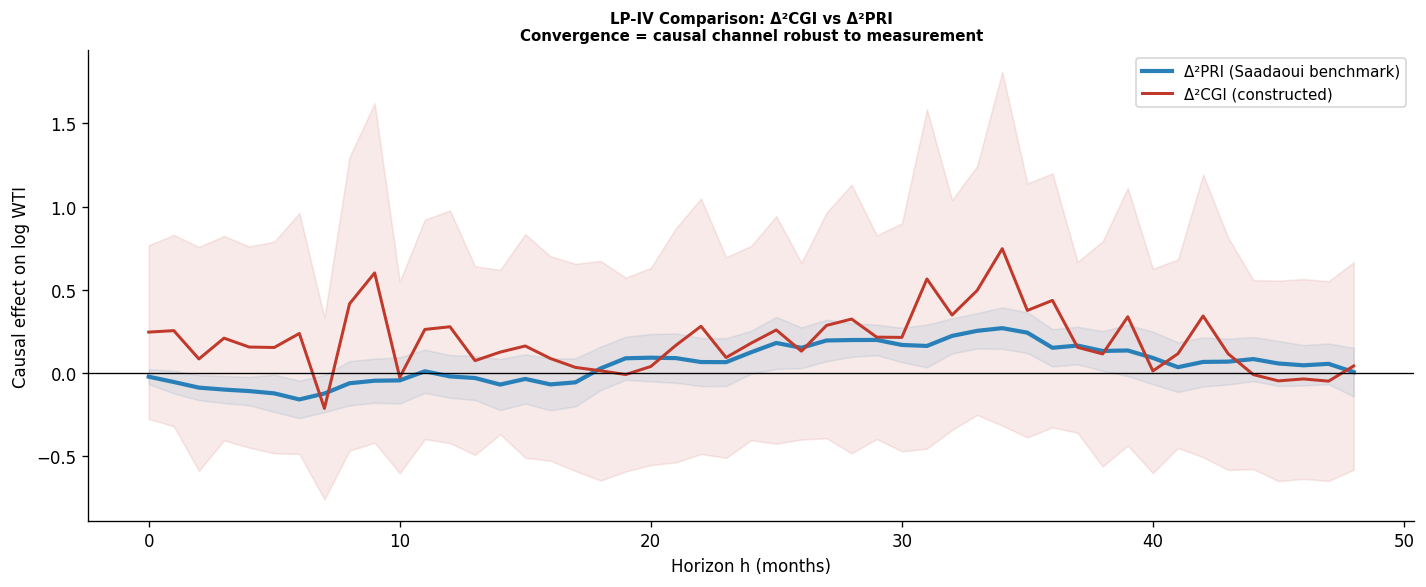

Saved: irf_cgi_vs_pri.png

LP-IV AT KEY HORIZONS:
   h     Δ²PRI (Saadaoui benc      Δ²CGI (constructed)
------------------------------------------------------------
   0     -0.0217(0.0272)          +0.2462(0.3169)     
   3     -0.0991(0.0498)*         +0.2099(0.3732)     
   6     -0.1583(0.0684)*         +0.2379(0.4397)     
  12     -0.0201(0.0781)          +0.2783(0.4247)     
  18     +0.0280(0.0796)          +0.0139(0.4007)     
  24     +0.1253(0.0786)          +0.1801(0.3549)     
  36     +0.1519(0.0680)*         +0.4366(0.4637)     
  48     +0.0057(0.0886)          +0.0429(0.3789)     
Saved: irf_comparison.csv


In [8]:
def run_lp_iv(data, h, controls, treatment, instrument, outcome):
    w = data.copy()
    w['_y'] = w[outcome].shift(-h)
    for l in range(1,4): w[f'_Ly{l}'] = w[outcome].shift(l)
    for l in range(1,3): w[f'_Lt{l}'] = w[treatment].shift(l)
    lags = [f'_Ly{l}' for l in range(1,4)] + [f'_Lt{l}' for l in range(1,3)]
    need = ['_y', instrument, treatment] + lags + controls
    sub = w[[c for c in need if c in w.columns]].replace([np.inf,-np.inf],np.nan).dropna()
    if len(sub) < 30: return None, None, 0
    cl = _prune(sub, lags + controls)
    exog = sub[cl].copy(); exog.insert(0,'const',1.0)
    try:
        fit = IV2SLS(sub['_y'], exog, sub[[treatment]], sub[[instrument]]).fit(cov_type='kernel')
        return float(fit.params[treatment]), float(fit.std_errors[treatment]), len(sub)
    except: return None, None, 0

HORIZONS = list(range(0, 49))

specs = []
if 'd2pri' in m.columns: specs.append(('d2pri','Δ²PRI (Saadaoui benchmark)','#2980B9'))
if 'delta2_cgi' in m.columns: specs.append(('delta2_cgi','Δ²CGI (constructed)','#C0392B'))

all_irfs = {}
for instr, label, color in specs:
    print(f'Running LP-IV: {label}...', end=' ', flush=True)
    irf = {'h':[],'coef':[],'se':[]}
    for h in HORIZONS:
        c, se, n = run_lp_iv(m, h, CONTROLS, 'lpri', instr, 'lwti')
        if c is not None:
            irf['h'].append(h); irf['coef'].append(c); irf['se'].append(se)
    n_sig = sum(1 for c,se in zip(irf['coef'],irf['se']) if se>0 and abs(c/se)>1.645)
    all_irfs[label] = (irf, color)
    print(f'{n_sig}/{len(irf["h"])} horizons significant at 10%')

# Plot
fig, ax = plt.subplots(figsize=(12, 5))
z90 = 1.645
for label, (irf, color) in all_irfs.items():
    hs = np.array(irf['h']); cs = np.array(irf['coef']); ses = np.array(irf['se'])
    lw = 2.5 if 'Saadaoui' in label else 1.8
    ax.plot(hs, cs, color=color, lw=lw, label=label)
    ax.fill_between(hs, cs-z90*ses, cs+z90*ses, alpha=0.10, color=color)
ax.axhline(0, color='black', lw=0.8)
ax.set_xlabel('Horizon h (months)')
ax.set_ylabel('Causal effect on log WTI')
ax.set_title('LP-IV Comparison: Δ²CGI vs Δ²PRI\n'
             'Convergence = causal channel robust to measurement', fontweight='bold', fontsize=9)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(OUT_DIAG / 'irf_cgi_vs_pri.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: irf_cgi_vs_pri.png')

# Table at key horizons
print()
print('LP-IV AT KEY HORIZONS:')
print(f'{"h":>4}' + ''.join(f'{l[:20]:>25}' for l,(_,__) in all_irfs.items()))
print('-'*60)
for h in [0,3,6,12,18,24,36,48]:
    row = f'{h:>4}'
    for label,(irf,_) in all_irfs.items():
        if h in irf['h']:
            idx = irf['h'].index(h)
            c,se = irf['coef'][idx], irf['se'][idx]
            star = '*' if se>0 and abs(c/se)>1.645 else ' '
            row += f'{c:>+.4f}({se:.4f}){star}'.center(25)
        else: row += 'n/a'.center(25)
    print(row)

rows=[]
for label,(irf,_) in all_irfs.items():
    for h,c,se in zip(irf['h'],irf['coef'],irf['se']):
        rows.append({'h':h,'instrument':label,'coef':c,'se':se})
pd.DataFrame(rows).to_csv(OUT_DIAG/'irf_comparison.csv',index=False)
print('Saved: irf_comparison.csv')


## Cell 9 — Save merged master panel

Save the full merged dataset (df_extended + composite GPR) as the input for the next notebook.


In [9]:
m.to_csv(OUT_DIAG / 'master_panel_with_gpr.csv')
print(f'Saved: master_panel_with_gpr.csv ({m.shape})')
print()
print('SUMMARY')
print('='*60)
print(f'  Composite GPR: {m["composite_gpr"].notna().sum()}/{len(m)} months')
print(f'  Δ²CGI:         {m["delta2_cgi"].notna().sum()}/{len(m)} months')
print()
f_cgi = f_results.get('delta2_cgi',{}).get('f', 0)
f_pri = f_results.get('d2pri',{}).get('f', 0)
print(f'  First-stage F (Δ²PRI):  {f_pri:.2f}')
print(f'  First-stage F (Δ²CGI): {f_cgi:.2f}')
print()
if f_cgi >= 10:
    print('NEXT NOTEBOOK: 04_dml_and_estimation.ipynb')
    print('  → Run DML with BOTH d2pri and delta2_cgi as instruments')
    print('  → Compare IRFs: agreement = measurement robustness finding')
else:
    print('NEXT NOTEBOOK: 04_dml_and_estimation.ipynb')
    print('  → Use d2pri as primary instrument')
    print('  → Add composite_gpr and sentiment_score_z as DML nuisance controls')
    print('  → Test whether adding NLP controls changes the causal estimate')
    print('  → Document Δ²CGI weakness as honest finding (narrative > automated coding)')


Saved: master_panel_with_gpr.csv ((385, 28))

SUMMARY
  Composite GPR: 385/385 months
  Δ²CGI:         384/385 months

  First-stage F (Δ²PRI):  244.40
  First-stage F (Δ²CGI): 1.61

NEXT NOTEBOOK: 04_dml_and_estimation.ipynb
  → Use d2pri as primary instrument
  → Add composite_gpr and sentiment_score_z as DML nuisance controls
  → Test whether adding NLP controls changes the causal estimate
  → Document Δ²CGI weakness as honest finding (narrative > automated coding)
